# Reproducing the paper's tables and figures

This notebook rebuilds the quantitative content of the UAI 2026 paper from the saved result CSVs shipped in `results/`; no GPU and no re-runs needed. Each section names the script that regenerates its CSV from scratch, so you can swap in your own runs.

| Section | Paper object | Saved results | Regenerate with |
|---|---|---|---|
| E1 certification | Table 3, Fig. 2 | `e1_certification.csv` | `code/e1_certified_iia.py` |
| E1 CS widths | Table 2, Fig. 1 | `e1_cs_traces.csv` | `code/e1_certified_iia.py` |
| E1 paired test | Sec. 5.1 | `e1_paired.csv` | `code/e1_certified_iia.py --paired-only` |
| E2 GPT-2 IOI | Table 4, Figs. 3-4 | `e2_patching_cs.csv`, `e2_completeness.csv` | `code/e2_gpt2_patching.py` |
| E3 metric sensitivity | Fig. 5 | `e3_sensitivity.csv` | `code/e3_sensitivity.py` |
| E4 coverage | appendix table | `e4_coverage.csv` | `code/e4_coverage.py` |
| Adaptive study | appendix | `adaptive_vs_iid_v2.csv`, `alpha_sweep.csv` | `code/adaptive_study*.py` |

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS = Path.cwd().parent / "results"
pd.set_option("display.width", 120)
%matplotlib inline

METHOD = {"cip-const": "Hard pruning", "cip-affine": "Soft interv.",
          "vbp": "Variance-based", "random": "Random"}

## E1: certified IIA on MNIST abstractions

Four abstraction methods at three pruning levels, evaluated under interchange interventions. At the mild swap probability $p=0.1$, the certification table shows the paper's headline contrast: the betting CS certifies $F \ge F_0$ in a small fraction of the samples the Hoeffding CS needs.

In [2]:
cert = pd.read_csv(RESULTS / "e1_certification.csv")
sub = cert[(cert.mask_p == 0.1) & (cert.sampling == "iid") & (cert.F_0.isin([0.90, 0.95]))].copy()
sub["n"] = sub.apply(lambda r: r.n_certify if r.certified else np.nan, axis=1)

tab = sub.pivot_table(index=["method", "keep"], columns=["F_0", "cs_type"], values="n")
tab = tab.rename(index=METHOD, level=0).sort_index()
speedup = (tab[(0.90, "hoeffding")] / tab[(0.90, "betting")]).round(1)
tab[("speedup @0.90", "")] = speedup
tab.fillna("--")

F_0                     0.9              0.95           speedup @0.90
cs_type             betting hoeffding betting hoeffding              
method         keep                                                  
Hard pruning   512     64.0     889.0   125.0    4172.0          13.9
Random         256    249.0    3549.0      --        --          14.3
               384     64.0    1081.0   228.0    7239.0          16.9
               512     64.0     889.0   125.0    4172.0          13.9
Soft interv.   64    1813.0        --      --        --            --
               128    131.0    3393.0      --        --          25.9
               256     93.0    1219.0   342.0    9849.0          13.1
               384     93.0    1081.0   233.0    6746.0          11.6
               512     64.0     889.0   125.0    4172.0          13.9
Variance-based 128   4725.0        --      --        --            --
               256     64.0    1141.0   252.0    6888.0          17.8
               384     64.0     933.0   125.0    4973.0          14.6
               512     64.0     889.0   125.0    4172.0          13.9

The width trajectories behind those stopping times, at the aggressive regime ($p=0.5$, hard pruning, $k=256$): the Hoeffding width depends only on $n$, while the betting CS adapts to the variance of the stream.

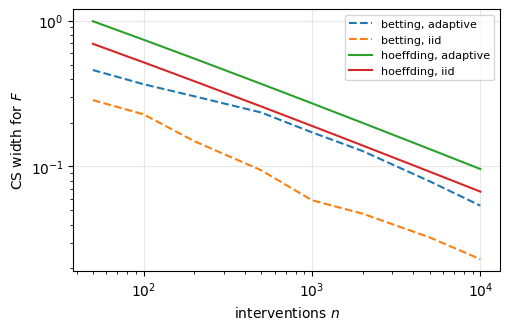

In [3]:
tr = pd.read_csv(RESULTS / "e1_cs_traces.csv")
sel = tr[(tr.method == "cip-const") & (tr.keep == 256) & (tr.mask_p == 0.5)]

fig, ax = plt.subplots(figsize=(5.5, 3.4))
for (cs, samp), g in sel.groupby(["cs_type", "sampling"]):
    ax.loglog(g.n, 2 * g.radius, label=f"{cs}, {samp}",
              linestyle="-" if cs == "hoeffding" else "--")
ax.set_xlabel("interventions $n$")
ax.set_ylabel("CS width for $F$")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

The paired comparison at $p=0.5$, $k=256$, $n=10{,}000$: the soft-intervention vs random-pruning gap is invisible to the paired Hoeffding CS but significant under betting, so the choice of CS changes the qualitative conclusion.

In [4]:
paired = pd.read_csv(RESULTS / "e1_paired.csv")
cols = ["cs_type", "pair", "mu_hat", "radius", "significant"]
paired[cols].sort_values(["pair", "cs_type"]).reset_index(drop=True)

,cs_type,pair,mu_hat,radius,significant
0,betting,cip-affine_vs_cip-const,-0.4556,0.022173,True
1,hoeffding,cip-affine_vs_cip-const,-0.4556,0.067242,True
2,betting,cip-affine_vs_random,-0.0327,0.015689,True
3,hoeffding,cip-affine_vs_random,-0.0327,0.067242,False
4,betting,cip-const_vs_vbp,0.5790,0.021157,True
5,hoeffding,cip-const_vs_vbp,0.5790,0.067242,True
6,betting,vbp_vs_random,-0.1561,0.016592,True
7,hoeffding,vbp_vs_random,-0.1561,0.067242,True


## E2: certified patching effects on GPT-2 Small (IOI)

Patching effects $\mu$ for IOI circuits of increasing size, evaluated at $n = 2{,}000$. The betting CS turns circuit certification into a ~100-forward-pass operation.

In [5]:
pcs = pd.read_csv(RESULTS / "e2_patching_cs.csv")
final = pcs[pcs.n == pcs.n.max()]
print("point estimates and CS radii at n = 2000:")
display(final.pivot_table(index="circuit_size", columns="cs_type",
                          values=["mu_hat", "radius", "lcb_mu"]).round(3))

comp = pd.read_csv(RESULTS / "e2_completeness.csv")
comp["n"] = comp.apply(lambda r: r.n_certify if r.certified else np.nan, axis=1)
tab2 = comp.pivot_table(index="circuit_size", columns=["threshold", "cs_type"], values="n")
print("samples to certify mu >= threshold ('--' = not within n=2000):")
tab2.fillna("--")

point estimates and CS radii at n = 2000:


lcb_mu            mu_hat            radius          
cs_type      betting hoeffding betting hoeffding betting hoeffding
circuit_size                                                      
3              0.944     0.878   0.962     0.962   0.018     0.085
7              0.942     0.875   0.959     0.959   0.018     0.085
9              0.952     0.888   0.972     0.972   0.018     0.085
11             0.952     0.888   0.972     0.972   0.018     0.085
13             0.953     0.889   0.973     0.973   0.018     0.085

samples to certify mu >= threshold ('--' = not within n=2000):


threshold       0.80              0.90              0.95
cs_type      betting hoeffding betting hoeffding betting
circuit_size                                            
3               51.5     403.0   145.5        --   840.0
7               55.5     411.0   153.5        --  1545.0
9               49.5     374.5   135.5    1973.0   413.0
11              49.5     374.0   133.0    1954.0   369.0
13              49.0     361.0   132.0    1875.0   357.0

## E3: sensitivity to the intervention distribution

Fidelity for one abstraction under three bounded discrepancy metrics, across swap probabilities. At mild perturbations the metrics agree within their confidence sequences; at $p=0.5$ they separate, showing the "metric hacking" risk that interval-free point estimates hide.

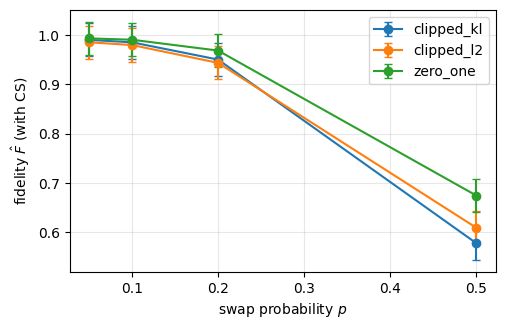

In [6]:
e3 = pd.read_csv(RESULTS / "e3_sensitivity.csv")
fig, ax = plt.subplots(figsize=(5.5, 3.4))
for metric, g in e3.groupby("metric"):
    g = g.sort_values("mask_p")
    ax.errorbar(g.mask_p, g.f_hat, yerr=g.radius, marker="o", capsize=3, label=metric)
ax.set_xlabel("swap probability $p$")
ax.set_ylabel("fidelity $\\hat F$ (with CS)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## E4: coverage validation

500 independent runs per protocol, including an adversarial peeking rule. Every configuration stays at or above its nominal coverage $1-\delta$; the Hoeffding CS is conservative, while the betting CS spends its error budget and gives tighter intervals.

In [7]:
e4 = pd.read_csv(RESULTS / "e4_coverage.csv")
view = e4.set_index(["protocol", "delta"])[
    ["empirical_coverage_hoeffding", "empirical_coverage_betting", "coverage_std_betting"]
]
view.columns = ["Hoeffding cov.", "Betting cov.", "Betting std"]
view.round(3)

,,Hoeffding cov.,Betting cov.,Betting std
protocol,delta,,,
iid,0.01,1.0,1.000,0.000
adaptive,0.01,1.0,1.000,0.000
aggressive_peeking,0.01,1.0,0.992,0.004
iid,0.05,1.0,0.998,0.002
adaptive,0.05,1.0,1.000,0.000
aggressive_peeking,0.05,1.0,0.966,0.008
iid,0.10,1.0,0.996,0.003
adaptive,0.10,1.0,0.996,0.003
aggressive_peeking,0.10,1.0,0.930,0.011


## Adaptive sampling study (paper Appendix E)

A matched five-seed comparison of i.i.d. sampling, the static weight-norm stress proposal, and a history-updated failure-rate proposal, in two regimes. The pattern is directional: adaptive proposals help exclude a low-fidelity abstraction and hurt borderline certification.

median    q1    q3
regime                   arm                        
borderline certification history    3800   806  4031
                         iid        1217   763  3263
                         static     1708  1501  3007
low-F exclusion          history     118   101   129
                         iid          88    86   150
                         static      201   151   219

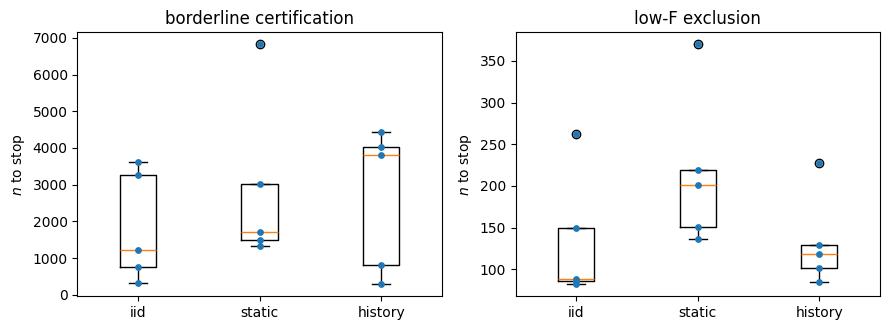

In [8]:
adf = pd.read_csv(RESULTS / "adaptive_vs_iid_v2.csv")
adf["arm"] = adf.proposal.fillna("iid")
adf["regime"] = np.where(adf.experiment.str.startswith("lowF"), "low-F exclusion", "borderline certification")

summ = adf.groupby(["regime", "arm"]).n_certify.agg(
    median="median", q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75)
).round(0).astype(int)
display(summ)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), sharey=False)
for ax, (regime, g) in zip(axes, adf.groupby("regime")):
    order = ["iid", "static", "history"]
    data = [g[g.arm == a].n_certify.values for a in order]
    ax.boxplot(data, tick_labels=order)
    ax.scatter(np.repeat([1, 2, 3], [len(d) for d in data]),
               np.concatenate(data), s=15, zorder=3)
    ax.set_title(regime)
    ax.set_ylabel("$n$ to stop")
plt.tight_layout()
plt.show()

The mixture rate $\alpha$ sets how much probability mass the stress proposal receives. Sweeping it on the borderline configuration shows the cost of large $\alpha$: the importance-weight bound $W_{\max} = 1/(1-\alpha)$ inflates certification time.

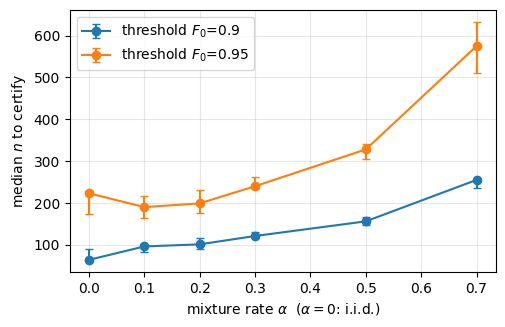

In [9]:
asw = pd.read_csv(RESULTS / "alpha_sweep.csv")
fig, ax = plt.subplots(figsize=(5.5, 3.4))
for f0, g in asw.groupby("F_0"):
    med = g.groupby("alpha").n_certify.median()
    q1 = g.groupby("alpha").n_certify.quantile(0.25)
    q3 = g.groupby("alpha").n_certify.quantile(0.75)
    ax.errorbar(med.index, med.values, yerr=[med - q1, q3 - med],
                marker="o", capsize=3, label=f"threshold $F_0$={f0}")
ax.set_xlabel("mixture rate $\\alpha$  ($\\alpha=0$: i.i.d.)")
ax.set_ylabel("median $n$ to certify")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Regenerating everything from scratch

```bash
python code/run_all.py                      # E1-E4 (MNIST auto-downloads; E2 pulls GPT-2 Small)
python code/e1_certified_iia.py --paired-only   # paired table only, from the cached checkpoint
python code/adaptive_study.py               # static-vs-iid + alpha sweep
python code/adaptive_study_history.py       # history-updated proposal arm
python code/adaptive_study_matched_seeds.py # matched low-F seeds
python code/plot_v2.py && python code/plot_adaptive.py   # paper figures
```

E1, E3, E4, and the adaptive study run on CPU in minutes; E2 benefits from a GPU.